---
title: "Heatmaps"
subtitle: "DS 2023 | Communicating with Data"
---

<img src="https://virginia.box.com/shared/static/k6qk3jrsmftvsurlzogfgm103e9icmwl.png"/>

## Overview

A **heatmap** displays a matrix of numbers as a grid of colored cells, where the color value in a cell is a function of the number value there.

Heatmaps show the relationship between **two grouping variables** and **a measurement variable** by using the visual channel of color to indicate intensity. 

> [!TIP]
>
> Think of a heatmap like a scatter plot for categorical data.
>
> In fact, we've seen how a scatter plot can be converted into a heatmap with the Matplotlib's `hexbin` function. 

## Use Cases

**Visualizing wide-form data**. Heatmaps can almost always be used to show the distribution of values in a wide table. As such, they are a good compliment to subplots generated from such tables. 

**Seeing structure in a large table at a glance.** The advantage of a heatmap is that it shows **two-dimensional patterns**: blocks, stripes and criss-crosses, and gaps jump out that you would never notice scanning raw numbers.

**Correlation and confusion matrices.** A square matrix of relationships between variables (or predicted-vs-actual class counts) is often  shown as a heatmap.

**Contingency matrices.** A heatmap can be used to show the pair-wise, co-ocurrence data. They are a good compliment to network diagrams of the same data.

## Creating a heatmap from scratch

Let's create a heatmap from scratch.

We'll use a dataset of passenger counts on airline flights grouped by year and month. 

This gives us a table of two grouping variables and a measurement one.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

flight_data_src = "https://virginia.box.com/shared/static/c8i3oyp8koeviixg2f9os7f0bgy869lf.csv"
flight = pd.read_csv(flight_data_src)
flight.info()
flight.head()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Years       144 non-null    int64
 1   Months      144 non-null    str  
 2   Passengers  144 non-null    int64
dtypes: int64(2), str(1)
memory usage: 4.4 KB


,Years,Months,Passengers
0,1949,January,112
1,1949,February,118
2,1949,March,132
3,1949,April,129
4,1949,May,121


To ensure that the months display in the right order, we convert these into `Categorical` data type.

In [5]:
flight.Months.unique()

<ArrowStringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [6]:
flight['Months'] = pd.Categorical(flight['Months'], categories=flight.Months.unique(), ordered=True)

**First, we create a wide dataframe.**

In [7]:
flight_wide = flight.pivot(columns='Years', index='Months', values='Passengers')
flight_wide.head()

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472


**Then, we scale all the values to be in $[0,1]$.**

$$v_{scaled} = \frac{v - v_{\min}}{v_{\max} - v_{\min}}, \qquad v_{scaled} \in [0, 1].$$

In [8]:
flight_wide_scaled = (flight_wide - flight_wide.min()) / (flight_wide.max() - flight_wide.min())
flight_wide_scaled

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,0.181818,0.017857,0.000000,0.000000,0.173913,0.140351,0.068702,0.091549,0.084337,0.153846,0.082949,0.116379
February,0.318182,0.214286,0.092593,0.126761,0.173913,0.000000,0.000000,0.042254,0.000000,0.041026,0.000000,0.004310
March,0.636364,0.482143,0.611111,0.309859,0.608696,0.412281,0.259542,0.323944,0.331325,0.266667,0.294931,0.125000
April,0.568182,0.375000,0.333333,0.140845,0.597826,0.342105,0.274809,0.295775,0.283133,0.194872,0.248848,0.306034
May,0.386364,0.196429,0.500000,0.169014,0.532609,0.403509,0.282443,0.330986,0.325301,0.271795,0.359447,0.353448
June,0.704545,0.625000,0.611111,0.661972,0.684783,0.666667,0.625954,0.725352,0.728916,0.641026,0.599078,0.625000
July,1.000000,1.000000,1.000000,0.830986,0.913043,1.000000,1.000000,1.000000,0.987952,0.928205,0.949309,1.000000
August,1.000000,1.000000,1.000000,1.000000,1.000000,0.921053,0.870229,0.943662,1.000000,1.000000,1.000000,0.931034
September,0.727273,0.785714,0.722222,0.535211,0.619565,0.622807,0.603053,0.591549,0.620482,0.482051,0.557604,0.508621


> [!NOTE]
>
> The values are scaled along axis 0, which means column-wise.
>
> This means that we are looking at the relative frequency of flights for each year. 
>
> You can see this by noting how each column has at least one value of $0$ and one of $1$.
>
> We might have also scaled them row-wise (axis 1) or table-wise (no axis).

**Next, we map the scaled values to the corresponding value on a color scale.**

Here we get a colormap object from Matplotlib called `YlGnBu`.

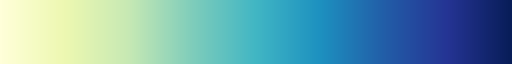

In [9]:
cmap = plt.colormaps["YlGnBu"]
cmap

The colormap as $256$ color values, show above as a gradient.

In [10]:
cmap.N

256

We can take any number in $[0, 1]$ and get the corresponding color code for it.

Here we see the results of converting $.5$, showing the result as an indexed series for demonstration purposes.

In [11]:
cmap_demo = pd.Series(cmap(.5), index=['r','g','b','a'])
cmap_demo

r    0.252687
g    0.711449
b    0.768381
a    1.000000
dtype: float64

Often, we will convert these values to $[0, 255]$.

In [12]:
(cmap_demo * 255).astype(int)

r     64
g    181
b    195
a    255
dtype: int64

Or, we convert to hexadecimal, the format that color codes are often expressed.

In [13]:
(cmap_demo * 255).astype(int).map(hex)

r    0x40
g    0xb5
b    0xc3
a    0xff
dtype: str

Now, we convert the dataframe to RGBA values.

In [14]:
flight_wide_scaled_mapped = flight_wide_scaled.map(cmap)
flight_wide_scaled_mapped

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,"(0.8633756247597079, 0.946482122260669, 0.6993...","(0.9911418685121107, 0.996555171088043, 0.8312...","(1.0, 1.0, 0.8509803921568627, 1.0)","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.872725874663591, 0.9501730103806229, 0.6985...","(0.914801999231065, 0.9667820069204152, 0.6952...","(0.9623529411764706, 0.985359477124183, 0.7673...","(0.9490657439446367, 0.9801922337562476, 0.737...","(0.9534948096885814, 0.9819146482122261, 0.747...","(0.8961014994232988, 0.9594002306805075, 0.696...","(0.9534948096885814, 0.9819146482122261, 0.747...","(0.9357785467128028, 0.9750249903883121, 0.708..."
February,"(0.6275893886966551, 0.8543021914648212, 0.720...","(0.8259746251441753, 0.9317185697808535, 0.702...","(0.9490657439446367, 0.9801922337562476, 0.737...","(0.9288273740868896, 0.972318339100346, 0.6941...","(0.872725874663591, 0.9501730103806229, 0.6985...","(1.0, 1.0, 0.8509803921568627, 1.0)","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9778546712802768, 0.9913879277201076, 0.801...","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9778546712802768, 0.9913879277201076, 0.801...","(1.0, 1.0, 0.8509803921568627, 1.0)","(0.9977854671280277, 0.9991387927720108, 0.846..."
March,"(0.11534025374855825, 0.552156862745098, 0.745...","(0.2892272202998847, 0.7264590542099193, 0.763...","(0.12867358708189156, 0.5839907727797001, 0.75...","(0.6453056516724337, 0.8611918492887352, 0.719...","(0.1331026528258362, 0.5885428681276432, 0.755...","(0.4265282583621684, 0.7773933102652826, 0.743...","(0.7604613610149944, 0.9059746251441754, 0.707...","(0.618731257208766, 0.8508573625528644, 0.7215...","(0.6010149942329873, 0.8439677047289504, 0.723...","(0.7427450980392157, 0.8990849673202614, 0.709...","(0.6807381776239908, 0.8749711649365628, 0.715...","(0.9288273740868896, 0.972318339100346, 0.6941..."
April,"(0.17739331026528254, 0.6340638216070742, 0.76...","(0.4951787773933103, 0.8028604382929643, 0.733...","(0.592156862745098, 0.8405228758169935, 0.7241...","(0.9101268742791234, 0.9649365628604383, 0.695...","(0.14196078431372547, 0.5976470588235294, 0.75...","(0.5744405997693195, 0.8336332179930797, 0.725...","(0.7250288350634372, 0.8921953094963475, 0.711...","(0.6807381776239908, 0.8749711649365628, 0.715...","(0.7073125720876586, 0.8853056516724337, 0.712...","(0.8493502499038832, 0.9409457900807382, 0.700...","(0.7838985005767013, 0.9151095732410611, 0.705...","(0.654163783160323, 0.864636678200692, 0.71815..."
May,"(0.4799231064975011, 0.797201076509035, 0.7359...","(0.8446751249519415, 0.9391003460207612, 0.700...","(0.2526874279123414, 0.7114494425221068, 0.768...","(0.8774009996155325, 0.9520184544405997, 0.698...","(0.21725490196078429, 0.6750326797385621, 0.76...","(0.4417839292579777, 0.7830526720492119, 0.741...","(0.7073125720876586, 0.8853056516724337, 0.712...","(0.6010149942329873, 0.8439677047289504, 0.723...","(0.6098731257208766, 0.8474125336409073, 0.722...","(0.7338869665513265, 0.8956401384083045, 0.710...","(0.5301499423298732, 0.8164090734332949, 0.730...","(0.5478662053056518, 0.8232987312572089, 0.728..."
June,"(0.12641291810841981, 0.43921568627451, 0.6920...","(0.11410995770857363, 0.5647058823529412, 0.75...","(0.12867358708189156, 0.5839907727797001, 0.75...","(0.11964628988850443, 0.508235294117647, 0.724...","(0.12333717800845828, 0.47058823529411764, 0.7...","(0.12026143790849673, 0.5019607843137255, 0.72...","(0.11410995770857363, 0.5647058823529412, 0.75...","(0.1294886582083814, 0.40784313725490196, 0.67...","(0.1301038062283737, 0.40156862745098043, 0.67...","(0.11657054978854285, 0.5396078431372551, 0.73...","(0.14196078431372547, 0.5976470588235294, 0.75...","(0.11410995770857363, 0.5647058823529412, 0.75..."
July,"(0.03137254901960784, 0.11372549019607843, 0.3...","(0.03137254901960784, 0.11372549019607843, 0.3...","(0.03137254901960784, 0.11372549019607843, 0.3...","(0.1409919261822376, 0.26140715109573254, 0.60...","(0.

Convert the RGB tuples into HTML entities.

In [15]:
(
    flight_wide_scaled_mapped
        .unstack()
        .apply(pd.Series)[[0,1,2]]
        .multiply(255)
        .astype(int)
        .apply(lambda x: f"#{x[0]:02x}{x[1]:02x}{x[2]:02x}", axis=1)
        .unstack()
        .T
        .style.map(lambda c: f'background-color: {c}')
)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,#dcf1b2,#fcfed3,#ffffd9,#ffffd9,#def2b2,#e9f6b1,#f5fbc3,#f2f9bc,#f3fabe,#e4f4b1,#f3fabe,#eef8b4
February,#a0d9b7,#d2edb3,#f2f9bc,#ecf7b1,#def2b2,#ffffd9,#ffffd9,#f9fccc,#ffffd9,#f9fccc,#ffffd9,#fefed7
March,#1d8cbe,#49b9c2,#2094c0,#a4dbb7,#2196c0,#6cc6bd,#c1e7b4,#9dd8b8,#99d7b8,#bde5b4,#addfb6,#ecf7b1
April,#2da1c1,#7eccbb,#97d6b8,#e8f6b1,#2498c0,#92d4b9,#b8e3b5,#addfb6,#b4e1b5,#d8efb2,#c7e9b3,#a6dcb7
May,#7acbbb,#d7efb2,#40b5c3,#dff2b2,#37acc2,#70c7bd,#b4e1b5,#99d7b8,#9bd8b8,#bbe4b5,#87d0ba,#8bd1b9
June,#2070b0,#1d90bf,#2094c0,#1e81b8,#1f78b4,#1e80b8,#1d90bf,#2168ac,#2166ab,#1d89bc,#2498c0,#1d90bf
July,#081d58,#081d58,#081d58,#23429a,#1c2c81,#081d58,#081d58,#081d58,#0a1f5d,#182979,#12256e,#081d58
August,#081d58,#081d58,#081d58,#081d58,#081d58,#1a2b7d,#243594,#142772,#081d58,#081d58,#081d58,#172978
September,#2166ab,#2251a1,#2069ad,#36aac2,#1e92c0,#1d91c0,#2397c0,#269ac1,#1e92c0,#49b9c2,#30a5c2,#3eb3c3


## Using Matplotlib

Matplotlib's `plt.imshow()` will take a 2D array and color each entry according to the specified colormap, defaulting to `viridis`. 

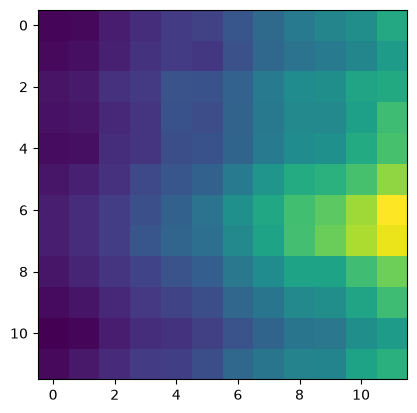

In [16]:
plt.imshow(flight_wide)
plt.show()

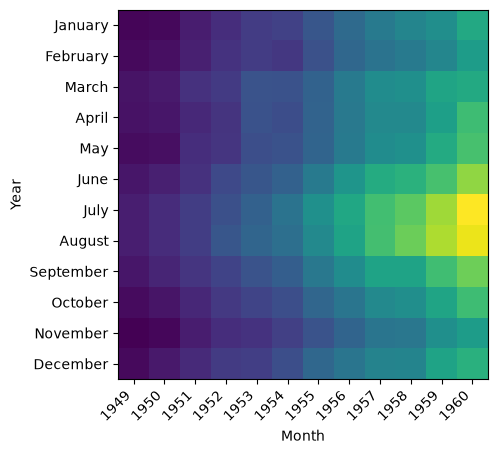

In [17]:
plt.imshow(flight_wide)
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

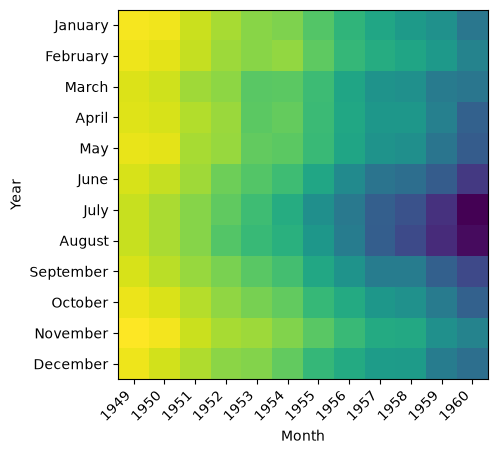

In [18]:
plt.imshow(flight_wide, cmap="viridis_r")
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

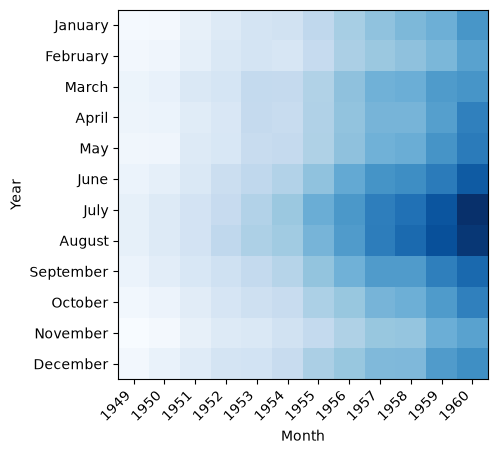

In [19]:
plt.imshow(flight_wide, cmap="Blues")
plt.xticks(range(len(flight_wide.columns)), labels=flight_wide.columns, rotation=45, ha='right')
plt.yticks(range(len(flight_wide.index)), labels=flight_wide.index)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

## Using Seaborn

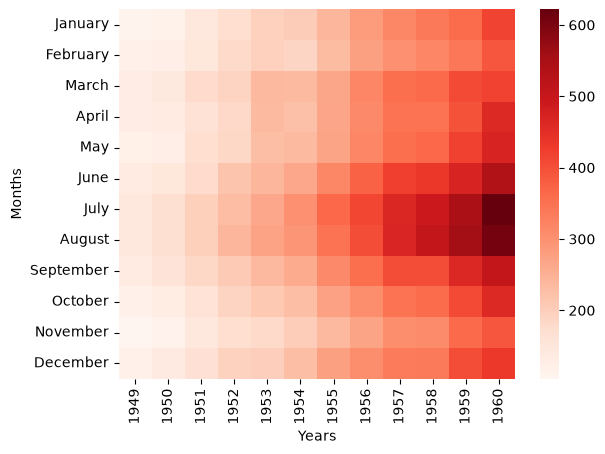

In [20]:
sns.heatmap(flight_wide, cmap='Reds')
plt.show()

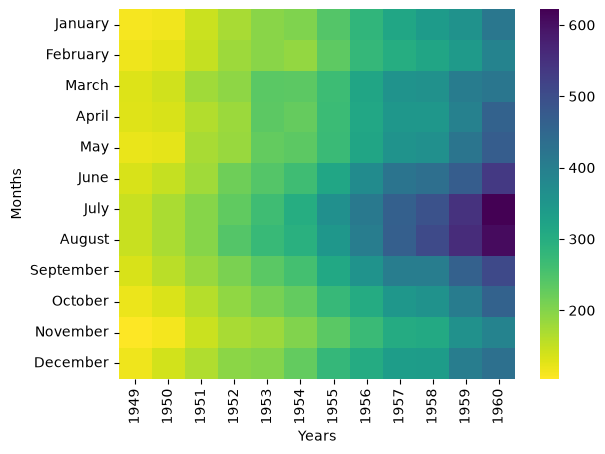

In [21]:
sns.heatmap(flight_wide, cmap='viridis_r')
plt.show()

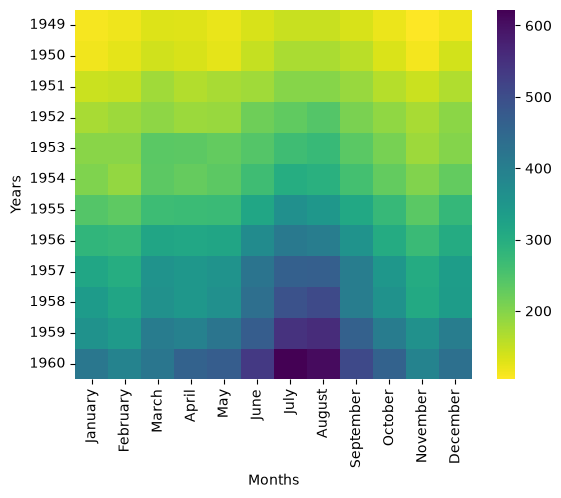

In [22]:
sns.heatmap(flight_wide.T, cmap='viridis_r')
plt.show()

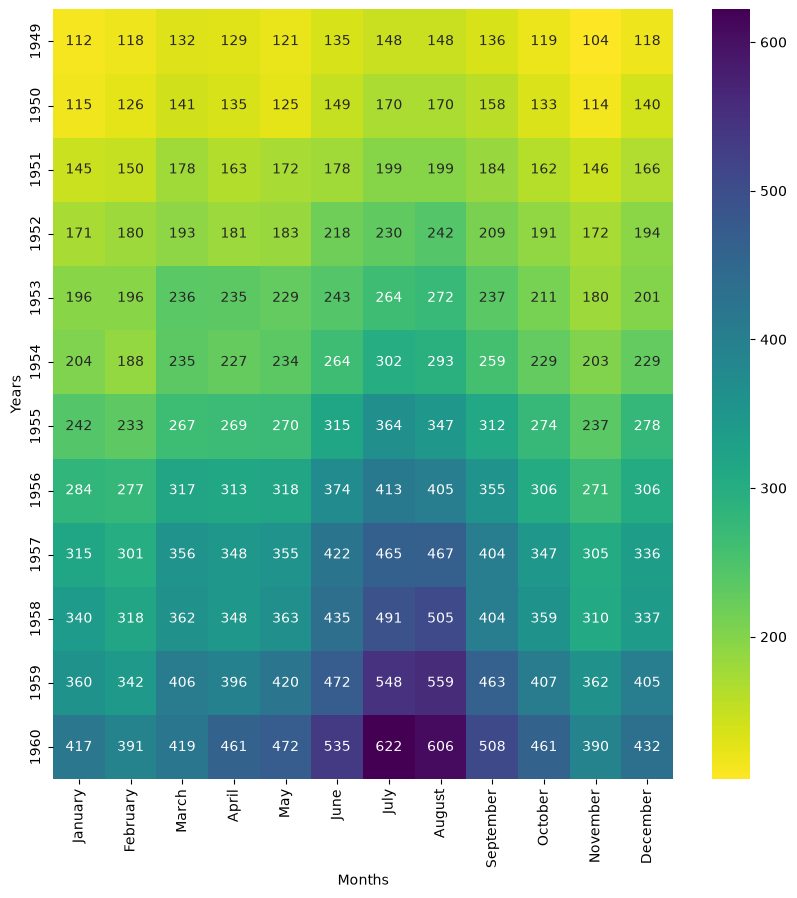

In [23]:
plt.figure(figsize=(10,10))
sns.heatmap(flight_wide.T, annot=True, fmt='d', cmap='viridis_r')
plt.show()

## Using Pandas

Because a heatmap is basically a colored-in wide-form table, Pandas let's you style a dataframe as a heatmap with `.style.background_gradient`.

In [24]:
flight_wide.style.background_gradient() # The gradient goes along axis=0 by default

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [25]:
flight_wide.style.background_gradient(axis=1)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [26]:
flight_wide.style.background_gradient(axis=None)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [27]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [28]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000)

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


In [29]:
flight_wide.style.background_gradient(axis=None, vmin=0, vmax=1000, cmap='YlGnBu')

Years,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
Months,,,,,,,,,,,,
January,112,115,145,171,196,204,242,284,315,340,360,417
February,118,126,150,180,196,188,233,277,301,318,342,391
March,132,141,178,193,236,235,267,317,356,362,406,419
April,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
June,135,149,178,218,243,264,315,374,422,435,472,535
July,148,170,199,230,264,302,364,413,465,491,548,622
August,148,170,199,242,272,293,347,405,467,505,559,606
September,136,158,184,209,237,259,312,355,404,404,463,508


## Using Plotly

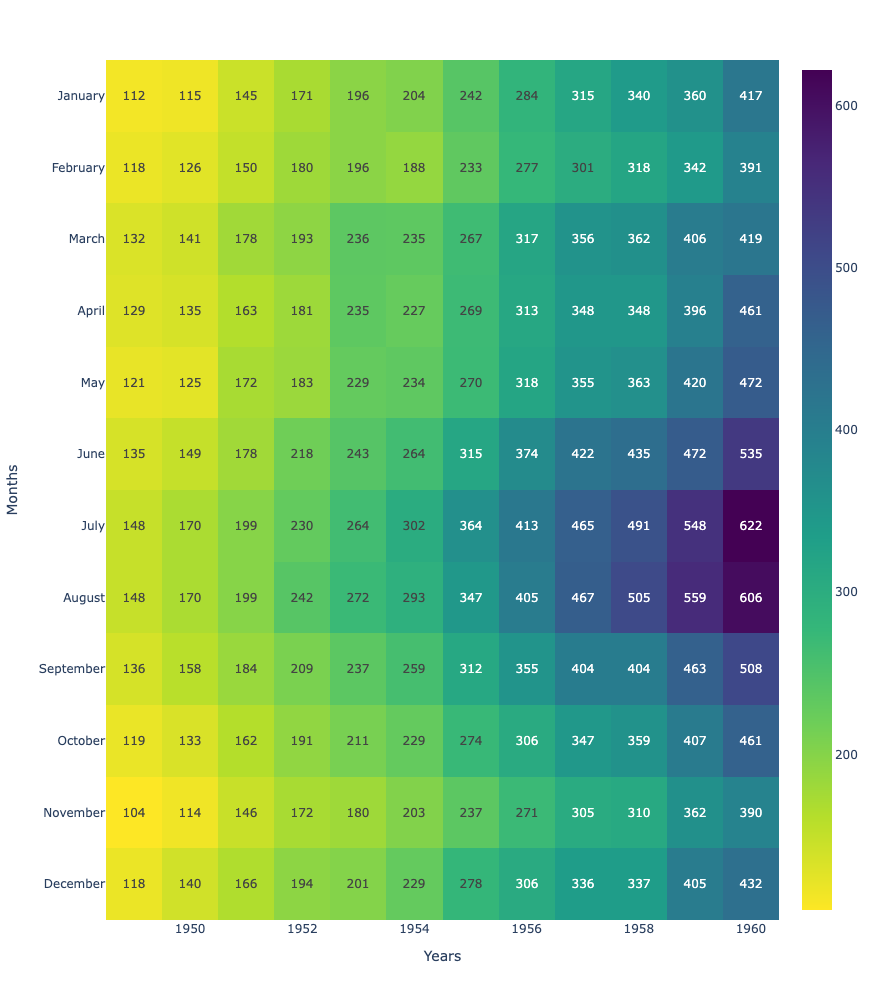

In [38]:
import plotly.express as px

px.imshow(flight_wide, text_auto=True, height=1000, color_continuous_scale='viridis_r')